# Cloning Test ZI

This notebook traces the VDP cloning path from S3M orbital-element tables to visible `(v_lambda, v_beta)` points and density-map smoothing diagnostics.

`clone_visible_df`: contains the cloned orbital elements and the velocity-map coordinates used in the plots.

## 0. Imports and Settings

In [38]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

NEOMOD_DIR = Path.cwd().resolve()
if not (NEOMOD_DIR / 'velocity_density_pipeline.py').exists():
    NEOMOD_DIR = Path('/Users/devanshisingh/Downloads/research/NEO_probability/neomod')
sys.path.insert(0, str(NEOMOD_DIR))

import velocity_density_pipeline as vdp

print('Using VDP:', Path(vdp.__file__).resolve())

Using VDP: /Users/devanshisingh/Downloads/research/NEO_probability/neomod/velocity_density_pipeline.py


In [39]:
OBSTIME_STR = '2026-05-09T22:00:00'
CENTER_LON_DEG = 229.0
CENTER_LAT_DEG = 0.0
MAX_SEP_DEG = 30.0

# For testing: increase these later
POP_TO_TEST = 'NEO'
MAX_SOURCE_OBJECTS = 5000
MAG_BIN_TO_TEST = 'mag21'
# Keep False for the dense baseline cloning diagnostic. Set True to test one mag bin only.
USE_MAG_BIN_FOR_CLONING = False
CLONE_FACTOR_TEST = 30
RNG_SEED = 42

# Density-map controls for the diagnostic section.
GRID_LIM = (-0.8, 0.8)
GRID_STEP = 0.02
K_MAP_TEST = 10
N_D0_GRID_TEST = 120

# Match the current production NEO smoothing behavior.
SMOOTH_PASSES = [
    {'support_threshold': 3.0, 'sigma_pixels': 1.5, 'truncate_sigma': 5.0},
    {'support_threshold': 10.0, 'sigma_pixels': 4.0, 'truncate_sigma': 5.0},
]
SCALE_SUPPORT_BY_CLONE_FACTOR = True

rng = np.random.default_rng(RNG_SEED)

## 1. Load S3M Populations

Each loaded DataFrame contains the S3M orbital elements plus a derived semi-major axis column `a`.

In [40]:
print('Loading MBA...')
df_mba, scorer_mba = vdp.load_s3m_population('mba', verbose=True)

print('\nLoading NEO...')
df_neo, scorer_neo = vdp.load_s3m_population('neo', verbose=True)

print('\nLoading TNO...')
df_tno, scorer_tno = vdp.load_s3m_population('tno', verbose=True)

print('\nLoading Trojans...')
df_trojan, scorer_trojan = vdp.load_s3m_population('trojan', verbose=True)

population_dfs = {
    'MBA': df_mba,
    'NEO': df_neo,
    'TNO': df_tno,
    'Trojans': df_trojan,
}
population_scorers = {
    'MBA': scorer_mba,
    'NEO': scorer_neo,
    'TNO': scorer_tno,
    'Trojans': scorer_trojan,
}

pd.DataFrame({name: {'rows': len(df), 'columns': len(df.columns)} for name, df in population_dfs.items()}).T

Loading MBA...
Search pattern: S1_*.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['S3Mdata/S1_00.s3m', 'S3Mdata/S1_01.s3m', 'S3Mdata/S1_02.s3m', 'S3Mdata/S1_03.s3m', 'S3Mdata/S1_04.s3m', 'S3Mdata/S1_05.s3m', 'S3Mdata/S1_06.s3m', 'S3Mdata/S1_07.s3m', 'S3Mdata/S1_08.s3m', 'S3Mdata/S1_09.s3m', 'S3Mdata/S1_10.s3m', 'S3Mdata/S1_11.s3m', 'S3Mdata/S1_12.s3m', 'S3Mdata/S1_13.s3m']
Loaded 14 file(s).
Final dataframe shape: (13883361, 15)
The final df is done.

Loading NEO...
Search pattern: S0.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['S3Mdata/S0.s3m']
Loaded 1 file(s).
Final dataframe shape: (268511, 15)
The final df is done.

Loading TNO...
Search pattern: ST.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['S3Mdata/ST.s3m']
Loaded 1 file(s).
Final dataframe shape: (48682, 15)
The final df is done.

Loading Trojans...
Search pattern: St5.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['S3Mdata/St5.s3m']
Loaded 1 file(s).
Final dataframe shape: (179882, 15)
The final df is done.

,rows,columns
MBA,13883361,15
NEO,268511,15
TNO,48682,15
Trojans,179882,15


## 2. Access Orbital Elements in the DataFrames

In [41]:
ORBIT_COLS = ['OID', 'a', 'q', 'e', 'i', 'node', 'argperi', 't_p', 'H']

df = population_dfs[POP_TO_TEST]
print('Columns in selected population:')
print(list(df.columns))

df[ORBIT_COLS].head()

Columns in selected population:
['OID', 'FORMAT', 'q', 'e', 'i', 'node', 'argperi', 't_p', 'H', 't_0', 'INDEX', 'N_PAR', 'MOID', 'COMPCODE', 'a']


,OID,a,q,e,i,node,argperi,t_p,H
0,S0000001a,2.025814,1.251459,0.382244,9.304721,252.063850,185.610748,54067.969964,10.315
1,S0000002a,3.811219,1.286219,0.662518,18.303865,132.486568,80.463153,54670.088589,10.818
2,S0000003a,1.739907,0.617193,0.645272,10.302493,67.484378,182.131418,54522.349738,11.175
3,S0000004a,2.669612,0.383306,0.856419,16.988463,117.793282,242.430598,54973.510299,11.452
4,S0000005a,2.498139,0.569264,0.772125,22.761089,314.323204,73.119299,54075.567352,11.678


In [42]:
df[ORBIT_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
a,268511.0,1.959882,0.705068,0.309999,1.451172,1.976464,2.420834,7.344929
q,268511.0,0.763699,0.340929,0.000404,0.497479,0.790870,1.059862,1.299996
e,268511.0,0.588102,0.187509,0.001983,0.461965,0.592353,0.725975,0.999457
i,268511.0,23.683501,17.126926,0.002902,10.094004,18.885782,33.587569,89.814587
node,268511.0,179.936817,103.803305,0.001529,90.003376,180.087413,269.678785,359.997723
argperi,268511.0,180.035285,103.802307,0.001371,90.481505,179.943199,270.014456,359.999636
t_p,268511.0,54466.457094,343.834508,51324.705697,54258.591858,54466.256086,54675.469382,57895.304070
H,268511.0,23.759334,1.240541,10.315000,23.280000,24.140000,24.643000,25.000000


## 3. Select a Test Sample

The full S3M files can be large. The following cells use a smaller subset for testing.

In [43]:
source_df_full = population_dfs[POP_TO_TEST].copy().reset_index(drop=True)

if MAX_SOURCE_OBJECTS is not None and len(source_df_full) > MAX_SOURCE_OBJECTS:
    sample_idx = rng.choice(len(source_df_full), size=MAX_SOURCE_OBJECTS, replace=False)
    source_df_sample = source_df_full.iloc[sample_idx].copy().reset_index(drop=True)
else:
    source_df_sample = source_df_full.copy().reset_index(drop=True)

source_df_sample['source_row'] = np.arange(len(source_df_sample), dtype=int)
source_df = source_df_sample.copy()

print(f'{POP_TO_TEST}: sampled {len(source_df_sample):,} source objects')
source_df_sample[ORBIT_COLS + ['source_row']].head()

NEO: sampled 5,000 source objects


,OID,a,q,e,i,node,argperi,t_p,H,source_row
0,S0000e5La,1.032104,0.873167,0.153994,19.698511,319.687247,325.910626,54585.654198,22.980,0
1,S00015uxa,1.906857,1.197672,0.371913,2.800536,192.580835,333.708763,54870.151972,24.923,1
2,S0000g3ha,1.329042,0.606291,0.543813,84.694611,159.903715,303.483375,54476.123773,23.141,2
3,S0000hB9a,2.133839,0.350374,0.835801,20.211003,83.162417,275.203412,54041.578723,23.255,3
4,S0000M7Va,5.211405,0.871733,0.832726,16.283101,167.474998,131.097383,55791.825144,24.504,4


## 4. Apparent-Magnitude Bin Split

Production VDP maps are generated separately by apparent-magnitude bin. This section attaches `mag_app`, counts the bins, and can restrict the cloning test to one bin (optional).

In [44]:
scorer = population_scorers[POP_TO_TEST]

mag_app = vdp.compute_apparent_magnitude_for_population(
    df=source_df_sample,
    obstime_str=OBSTIME_STR,
    scorer=scorer,
    chunk=50_000,
    show_progress=True,
)

source_df_with_mag = source_df_sample.copy()
source_df_with_mag['mag_app'] = mag_app

def assign_mag_bin(mag):
    if not np.isfinite(mag):
        return None
    for mb in vdp.DEFAULT_MAG_BINS:
        if mb['mag_min'] <= mag < mb['mag_max']:
            return mb['label']
    return None

source_df_with_mag['mag_bin_label'] = [assign_mag_bin(m) for m in source_df_with_mag['mag_app']]

bin_summary = []
for mb in vdp.DEFAULT_MAG_BINS:
    in_bin = source_df_with_mag['mag_bin_label'] == mb['label']
    bin_summary.append({
        'label': mb['label'],
        'mag_min': mb['mag_min'],
        'mag_max': mb['mag_max'],
        'n_sample': int(in_bin.sum()),
    })
bin_summary.append({
    'label': 'outside_bins',
    'mag_min': np.nan,
    'mag_max': np.nan,
    'n_sample': int(source_df_with_mag['mag_bin_label'].isna().sum()),
})

pd.DataFrame(bin_summary)

Propagate with newton: 100%|██████████| 1/1 [00:00<00:00, 564.66it/s]


,label,mag_min,mag_max,n_sample
0,14_16,14.0,16.0,0
1,16_18,16.0,18.0,1
2,18_20,18.0,20.0,6
3,mag20,20.0,21.0,13
4,mag21,21.0,22.0,20
5,mag22,22.0,23.0,48
6,mag23,23.0,24.0,117
7,mag24+,24.0,25.0,212
8,outside_bins,NaN,NaN,4583


In [45]:
magbin_source_df = source_df_with_mag[
    source_df_with_mag['mag_bin_label'] == MAG_BIN_TO_TEST
].copy().reset_index(drop=True)

print(f'Magnitude bin selected: {MAG_BIN_TO_TEST}')
print('Rows in selected bin:', len(magbin_source_df))

if USE_MAG_BIN_FOR_CLONING:
    if len(magbin_source_df) == 0:
        raise ValueError(f'No sampled objects in magnitude bin {MAG_BIN_TO_TEST!r}. Increase MAX_SOURCE_OBJECTS or choose another bin.')
    source_df = magbin_source_df.copy()
    print('Cloning input restricted to selected magnitude bin.')
    if len(source_df) < 200:
        print('Warning: selected bin has few sampled source rows; velocity plots may look sparse. Increase MAX_SOURCE_OBJECTS or CLONE_FACTOR_TEST for a denser test.')
else:
    source_df = source_df_with_mag.copy()
    print('Cloning input uses the full sampled source table. The magnitude-bin table above is for inspection.')

display_cols = ORBIT_COLS + ['source_row', 'mag_app', 'mag_bin_label']
source_df[display_cols].head(15)

Magnitude bin selected: mag21
Rows in selected bin: 20
Cloning input uses the full sampled source table. The magnitude-bin table above is for inspection.


,OID,a,q,e,i,node,argperi,t_p,H,source_row,mag_app,mag_bin_label
0,S0000e5La,1.032104,0.873167,0.153994,19.698511,319.687247,325.910626,54585.654198,22.980,0,25.376182,None
1,S00015uxa,1.906857,1.197672,0.371913,2.800536,192.580835,333.708763,54870.151972,24.923,1,30.399782,None
2,S0000g3ha,1.329042,0.606291,0.543813,84.694611,159.903715,303.483375,54476.123773,23.141,2,24.803092,mag24+
3,S0000hB9a,2.133839,0.350374,0.835801,20.211003,83.162417,275.203412,54041.578723,23.255,3,29.207815,None
4,S0000M7Va,5.211405,0.871733,0.832726,16.283101,167.474998,131.097383,55791.825144,24.504,4,33.987859,None
5,S0000TiNa,2.462124,0.235899,0.904189,33.804284,46.583328,193.319432,54512.210800,24.676,5,31.626617,None
6,S0000HBVa,1.689137,1.246675,0.261946,43.204370,72.287524,12.019280,54141.023505,24.381,6,28.490659,None
7,S00002Tya,1.820014,0.293429,0.838776,12.447192,104.095386,337.521874,54469.611805,21.016,7,26.384400,None
8,S0000RO1a,3.067356,1.170745,0.618321,15.102691,20.697528,82.489849,55023.256411,24.642,8,28.592030,None
9,S0000HTMa,2.795065,0.931422,0.666762,12.706890,93.801389,326.375421,53656.260157,24.389,9,30.687203,None


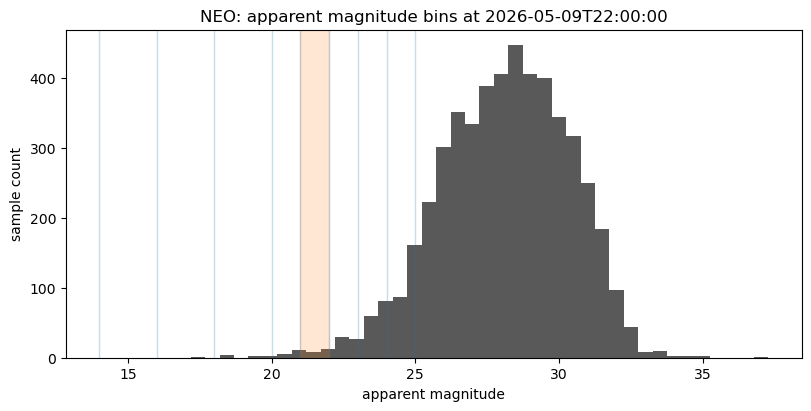

In [46]:
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
finite_mag = np.isfinite(source_df_with_mag['mag_app'])
ax.hist(source_df_with_mag.loc[finite_mag, 'mag_app'], bins=40, color='0.35')

for mb in vdp.DEFAULT_MAG_BINS:
    ax.axvline(mb['mag_min'], color='tab:blue', alpha=0.25, lw=1)
ax.axvline(vdp.DEFAULT_MAG_BINS[-1]['mag_max'], color='tab:blue', alpha=0.25, lw=1)

selected_mbin = next(mb for mb in vdp.DEFAULT_MAG_BINS if mb['label'] == MAG_BIN_TO_TEST)
ax.axvspan(selected_mbin['mag_min'], selected_mbin['mag_max'], color='tab:orange', alpha=0.18)
ax.set_xlabel('apparent magnitude')
ax.set_ylabel('sample count')
ax.set_title(f'{POP_TO_TEST}: apparent magnitude bins at {OBSTIME_STR}')
plt.show()

## 5. Clone Orbital Elements Directly

`clone_population_conditional_K_from_M` returns cloned orbital-element arrays. The test table below helps in checking the clone inputs after propagation.

In [47]:
a_rep, e_rep, inc_rep, node_rep, argperi_rep, tp_rep, clone_diag = (
    vdp.clone_population_conditional_K_from_M(
        df=source_df,
        clone_factor=CLONE_FACTOR_TEST,
        obstime_str=OBSTIME_STR,
        rng=rng,
        return_diagnostics=True,
    )
)

parent_row = np.repeat(source_df['source_row'].to_numpy(), CLONE_FACTOR_TEST)
parent_oid = np.repeat(source_df['OID'].to_numpy(), CLONE_FACTOR_TEST)
parent_H = np.repeat(source_df['H'].to_numpy(dtype=float), CLONE_FACTOR_TEST)

raw_clone_df = pd.DataFrame({
    'parent_row': parent_row,
    'parent_OID': parent_oid,
    'a': a_rep.astype(float),
    'e': e_rep.astype(float),
    'i': inc_rep.astype(float),
    'node': node_rep.astype(float),
    'argperi': argperi_rep.astype(float),
    't_p': tp_rep.astype(float),
    'H': parent_H.astype(float),
})

print('Raw cloned orbital-element table:', raw_clone_df.shape)
raw_clone_df.head()

Raw cloned orbital-element table: (150000, 9)


,parent_row,parent_OID,a,e,i,node,argperi,t_p,H
0,0,S0000e5La,1.032104,0.153994,19.698511,319.687256,0.774689,61023.367188,22.98
1,0,S0000e5La,1.032104,0.153994,19.698511,319.687256,159.200638,60999.226562,22.98
2,0,S0000e5La,1.032104,0.153994,19.698511,319.687256,355.904480,60979.910156,22.98
3,0,S0000e5La,1.032104,0.153994,19.698511,319.687256,277.723785,60811.167969,22.98
4,0,S0000e5La,1.032104,0.153994,19.698511,319.687256,0.797485,61078.121094,22.98


In [48]:
#From the conditional K|M sampler.
pd.DataFrame({
    'M_parent_deg': clone_diag['M_parent_deg'][:10],
    'M_clone_deg': clone_diag['M_clone_deg'][:10],
    'K_clone_deg': clone_diag['K_clone_deg'][:10],
    'clone_bin': clone_diag['clone_bin'][:10],
})

,M_parent_deg,M_clone_deg,K_clone_deg,clone_bin
0,69.075501,137.753147,320.461945,13
1,198.040766,160.444058,118.887894,16
2,345.945260,178.602536,315.591721,17
3,93.978726,337.214849,237.411041,33
4,85.553633,86.287674,320.484741,8
5,258.493438,63.934026,200.322563,6
6,275.686148,195.067708,133.606262,19
7,169.593698,274.573454,108.767780,27
8,47.709002,165.152925,341.382042,16
9,144.774911,20.329998,304.424820,2


## 6. Propagate Clones to the Velocity-Map Coordinates

`build_visible_subset_dataframe` adds sky position, ecliptic coordinates, and angular velocity columns. The same DataFrame keeps the cloned orbital elements.

In [49]:
scorer = population_scorers[POP_TO_TEST]

clone_visible_df = vdp.build_visible_subset_dataframe(
    raw_clone_df,
    obstime_str=OBSTIME_STR,
    scorer=scorer,
    max_sep_deg=MAX_SEP_DEG,
    center_mode='custom_ecliptic',
    center_lon_deg=CENTER_LON_DEG,
    center_lat_deg=CENTER_LAT_DEG,
    chunk=50_000,
    show_progress=True,
)

print('Visible cloned table:', clone_visible_df.shape)
print('Columns:', list(clone_visible_df.columns))

Propagate with newton: 100%|██████████| 3/3 [00:00<00:00, 84.27it/s]

Visible cloned table: (6884, 20)
Columns: ['parent_row', 'parent_OID', 'a', 'e', 'i', 'node', 'argperi', 't_p', 'H', 'ra_deg', 'dec_deg', 'dra_deg_day', 'ddec_deg_day', 'sky_sep_deg', 'lam_deg', 'beta_deg', 'vlam', 'vbeta', 'M_obs_deg', 'L_obs_deg']


In [50]:
MAP_INPUT_COLS = [
    'parent_row', 'parent_OID',
    'a', 'e', 'i', 'node', 'argperi', 't_p', 'H',
    'ra_deg', 'dec_deg', 'lam_deg', 'beta_deg', 'vlam', 'vbeta', 'sky_sep_deg',
]

clone_visible_df[MAP_INPUT_COLS].head(10)

,parent_row,parent_OID,a,e,i,node,argperi,t_p,H,ra_deg,dec_deg,lam_deg,beta_deg,vlam,vbeta,sky_sep_deg
0,1,S00015uxa,1.906857,0.371913,2.800535,192.580841,207.052521,60710.902344,24.923,205.963278,-8.888179,207.291349,1.736138,-0.262909,0.007989,21.778474
1,3,S0000hB9a,2.133839,0.835801,20.211002,83.162415,286.383514,60206.023438,23.255,217.185192,10.208510,211.220899,23.529057,-0.476868,-0.065003,29.184914
2,3,S0000hB9a,2.133839,0.835801,20.211002,83.162415,294.931641,60229.238281,23.255,225.250814,4.357417,221.428289,20.572440,-0.439550,-0.033445,21.866048
3,3,S0000hB9a,2.133839,0.835801,20.211002,83.162415,342.658569,60571.304688,23.255,254.302145,-15.504503,254.767415,7.108545,-0.230637,-0.005096,26.661505
4,3,S0000hB9a,2.133839,0.835801,20.211002,83.162415,338.512756,60921.093750,23.255,224.763856,3.376101,221.247541,19.490688,-0.361687,-0.069288,20.921423
5,3,S0000hB9a,2.133839,0.835801,20.211002,83.162415,329.266205,60336.539062,23.255,256.277935,-15.418798,256.668264,7.387688,-0.251713,-0.005876,28.558423
6,3,S0000hB9a,2.133839,0.835801,20.211002,83.162415,1.490524,60986.156250,23.255,247.341294,-8.336013,246.940382,13.307791,-0.441613,-0.044382,22.202969
7,3,S0000hB9a,2.133839,0.835801,20.211002,83.162415,337.984741,60698.375000,23.255,240.962177,-8.304071,240.565527,12.217386,-0.273499,-0.009358,16.760035
8,4,S0000M7Va,5.211405,0.832726,16.283102,167.474991,216.589523,58806.640625,24.504,205.243016,1.642128,202.780865,11.294833,-0.089715,-0.005955,28.392999
9,4,S0000M7Va,5.211405,0.832726,16.283102,167.474991,249.160690,59695.867188,24.504,227.193114,-1.325039,225.116975,15.696069,-0.109882,0.000468,16.158417


## 7. Access the Orbital Elements Behind a Velocity-Space Location

In [51]:
target_vlam = float(np.nanmedian(clone_visible_df['vlam']))
target_vbeta = float(np.nanmedian(clone_visible_df['vbeta']))
dv = 0.03

near_velocity_point = clone_visible_df[
    (np.abs(clone_visible_df['vlam'] - target_vlam) <= dv) &
    (np.abs(clone_visible_df['vbeta'] - target_vbeta) <= dv)
].copy()

print('Target velocity:', target_vlam, target_vbeta)
print('Rows in box:', len(near_velocity_point))
near_velocity_point[MAP_INPUT_COLS].head(20)

Target velocity: -0.272903554917988 -0.0008694637906909177
Rows in box: 1155


,parent_row,parent_OID,a,e,i,node,argperi,t_p,H,ra_deg,dec_deg,lam_deg,beta_deg,vlam,vbeta,sky_sep_deg
0,1,S00015uxa,1.906857,0.371913,2.800535,192.580841,207.052521,60710.902344,24.923,205.963278,-8.888179,207.291349,1.736138,-0.262909,0.007989,21.778474
5,3,S0000hB9a,2.133839,0.835801,20.211002,83.162415,329.266205,60336.539062,23.255,256.277935,-15.418798,256.668264,7.387688,-0.251713,-0.005876,28.558423
7,3,S0000hB9a,2.133839,0.835801,20.211002,83.162415,337.984741,60698.375000,23.255,240.962177,-8.304071,240.565527,12.217386,-0.273499,-0.009358,16.760035
15,5,S0000TiNa,2.462124,0.904189,33.804283,46.583328,344.660828,60232.925781,24.676,216.693133,-8.422236,217.131180,5.781746,-0.251260,-0.029184,13.187460
37,17,S0000p7Ca,1.890017,0.457738,2.599875,177.066254,219.273239,60716.664062,23.697,203.008970,-7.117288,203.921027,2.327212,-0.253207,0.001295,25.183612
39,17,S0000p7Ca,1.890017,0.457738,2.599875,177.066254,219.273239,60706.839844,23.697,205.283444,-7.888347,206.304111,2.427982,-0.263974,0.001592,22.822408
56,37,S0000rzDa,2.612448,0.522605,13.092999,183.388107,258.795654,60786.792969,23.812,221.697498,-3.245666,220.284124,12.253110,-0.248952,0.015311,15.000270
61,39,S00015lAa,2.192363,0.672062,11.703107,311.170837,84.381065,60553.691406,24.921,204.554556,-27.318076,212.824924,-15.914069,-0.249713,0.021782,22.543609
63,42,S0000iuba,1.839270,0.728838,14.189513,258.831696,160.738373,60692.539062,23.316,245.189352,-27.599834,248.041152,-6.032261,-0.291038,0.015859,19.936308
66,42,S0000iuba,1.839270,0.728838,14.189513,258.831696,163.514664,60711.468750,23.316,246.882262,-27.462289,249.507700,-5.652746,-0.286863,0.016187,21.236385


## 8. Velocity-Space Scatter and Granularity

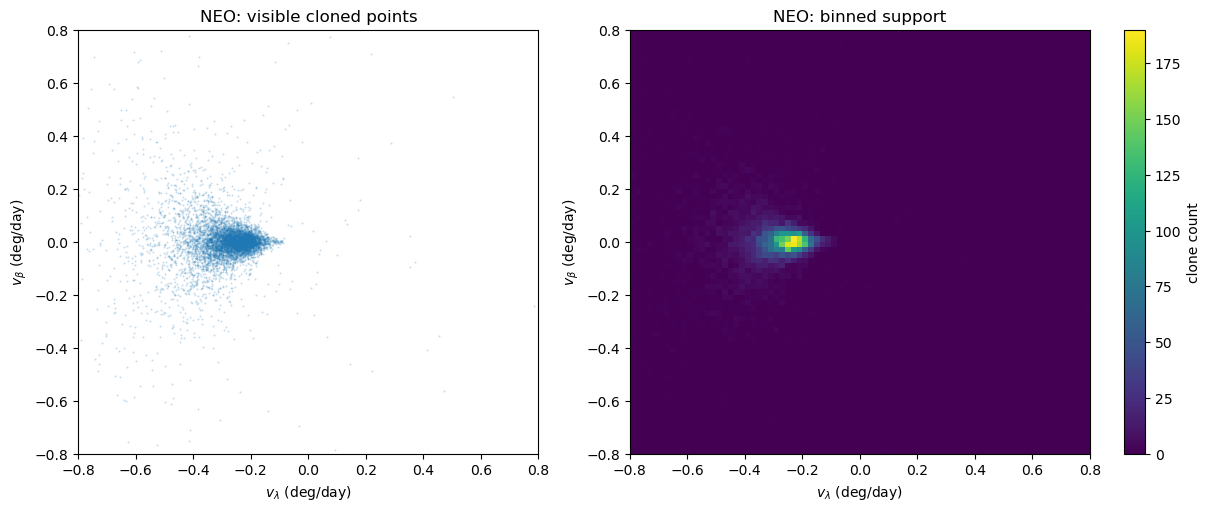

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

axes[0].scatter(
    clone_visible_df['vlam'], clone_visible_df['vbeta'],
    s=2, alpha=0.25, linewidths=0,
)
axes[0].set_title(f'{POP_TO_TEST}: visible cloned points')
axes[0].set_xlabel(r'$v_\lambda$ (deg/day)')
axes[0].set_ylabel(r'$v_\beta$ (deg/day)')
axes[0].set_xlim(*GRID_LIM)
axes[0].set_ylim(*GRID_LIM)

h = axes[1].hist2d(
    clone_visible_df['vlam'], clone_visible_df['vbeta'],
    bins=80, range=[GRID_LIM, GRID_LIM], cmap='viridis',
)
axes[1].set_title(f'{POP_TO_TEST}: binned support')
axes[1].set_xlabel(r'$v_\lambda$ (deg/day)')
axes[1].set_ylabel(r'$v_\beta$ (deg/day)')
fig.colorbar(h[3], ax=axes[1], label='clone count')

plt.show()

## 9. Build a Test Density Map

In [53]:
x_grid, y_grid, X0, Y0, grid_points = vdp.make_default_grid(
    grid_lim=GRID_LIM,
    grid_step=GRID_STEP,
)

pts = clone_visible_df[['vlam', 'vbeta']].to_numpy(dtype=float)
good_pts = np.isfinite(pts).all(axis=1)
pts = pts[good_pts]

print('Finite velocity points:', len(pts))

if len(pts) < 3:
    raise ValueError('Too few visible points for density-map diagnostic. Increase MAX_SOURCE_OBJECTS or CLONE_FACTOR_TEST.')

tree = cKDTree(pts)
k_eff = min(K_MAP_TEST, len(pts) - 1)
density_flat = vdp.evaluate_density_map_full_posterior_2d(
    tree,
    grid_points,
    k=k_eff,
    n_d0_grid=N_D0_GRID_TEST,
    show_progress=True,
)
density_raw = density_flat.reshape(X0.shape) / CLONE_FACTOR_TEST

support_count = vdp.make_support_count_map(
    pts[:, 0], pts[:, 1], x_grid, y_grid, clone_factor=CLONE_FACTOR_TEST,
)

print('k_eff:', k_eff)
print('raw density max:', float(np.nanmax(density_raw)))
print('support max:', float(np.nanmax(support_count)))

Finite velocity points: 6884


Evaluating density map: 100%|██████████| 6561/6561 [00:13<00:00, 483.60it/s]

k_eff: 10
raw density max: 19938.580580742455
support max: 201.0


## 10. Apply the Production-Style Smoothing Passes

In [54]:
density_smoothed = density_raw.copy()
support_for_smoothing = support_count * CLONE_FACTOR_TEST if SCALE_SUPPORT_BY_CLONE_FACTOR else support_count

for pass_cfg in SMOOTH_PASSES:
    density_smoothed = vdp.smooth_density_map_by_support(
        density_smoothed,
        support_for_smoothing,
        support_threshold=pass_cfg['support_threshold'],
        sigma_pixels=pass_cfg['sigma_pixels'],
        truncate_sigma=pass_cfg['truncate_sigma'],
    )

density_delta = density_smoothed - density_raw

print('smoothing passes:', SMOOTH_PASSES)
print('support scaled by clone factor:', SCALE_SUPPORT_BY_CLONE_FACTOR)
print('smoothed density max:', float(np.nanmax(density_smoothed)))
print('median |delta|:', float(np.nanmedian(np.abs(density_delta))))

smoothing passes: [{'support_threshold': 3.0, 'sigma_pixels': 1.5, 'truncate_sigma': 5.0}, {'support_threshold': 10.0, 'sigma_pixels': 4.0, 'truncate_sigma': 5.0}]
support scaled by clone factor: True
smoothed density max: 3295.7423710224934
median |delta|: 0.0


## 11. Density Smoothing Difference Plot

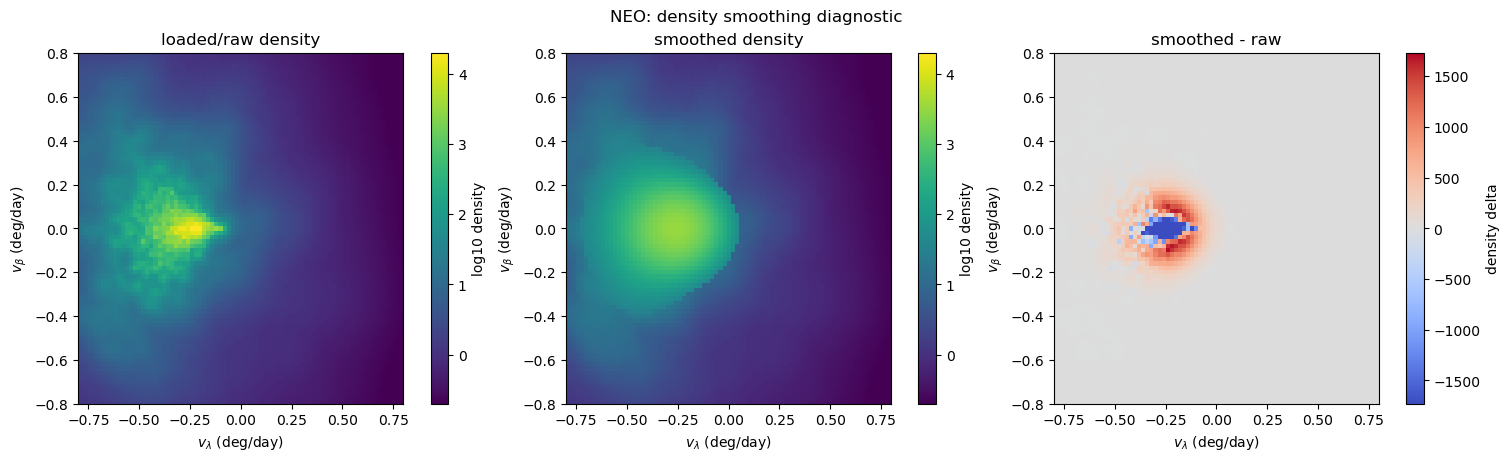

In [55]:
def density_log_map(density, floor=1e-30):
    data = np.log10(np.maximum(density, floor))
    finite = np.isfinite(data)
    if not np.any(finite):
        return data, -1.0, 1.0
    vmax = float(np.nanmax(data[finite]))
    return data, vmax - 5.0, vmax


raw_log, vmin, vmax = density_log_map(density_raw)
smooth_log, _, _ = density_log_map(density_smoothed)

lim = np.nanpercentile(np.abs(density_delta), 99.5)
if not np.isfinite(lim) or lim == 0:
    lim = 1.0

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

im0 = axes[0].pcolormesh(X0, Y0, raw_log, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
axes[0].set_title('loaded/raw density')
fig.colorbar(im0, ax=axes[0], label='log10 density')

im1 = axes[1].pcolormesh(X0, Y0, smooth_log, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
axes[1].set_title('smoothed density')
fig.colorbar(im1, ax=axes[1], label='log10 density')

im2 = axes[2].pcolormesh(X0, Y0, density_delta, shading='auto', cmap='coolwarm', vmin=-lim, vmax=lim)
axes[2].set_title('smoothed - raw')
fig.colorbar(im2, ax=axes[2], label='density delta')

for ax in axes:
    ax.set_xlim(*GRID_LIM)
    ax.set_ylim(*GRID_LIM)
    ax.set_xlabel(r'$v_\lambda$ (deg/day)')
    ax.set_ylabel(r'$v_\beta$ (deg/day)')

fig.suptitle(f'{POP_TO_TEST}: density smoothing diagnostic')
plt.show()

## 12. Pull Orbital Elements from a Region in the Density Map

Use this pattern to inspect the cloned orbital elements contributing to any velocity-space region.

In [56]:
REGION_CENTER = (-0.25, 0.0)
REGION_HALF_WIDTH = 0.05

region_rows = clone_visible_df[
    (np.abs(clone_visible_df['vlam'] - REGION_CENTER[0]) <= REGION_HALF_WIDTH) &
    (np.abs(clone_visible_df['vbeta'] - REGION_CENTER[1]) <= REGION_HALF_WIDTH)
].copy()

print('Region center:', REGION_CENTER)
print('Rows in region:', len(region_rows))
region_rows[MAP_INPUT_COLS].head(30)

Region center: (-0.25, 0.0)
Rows in region: 2779


,parent_row,parent_OID,a,e,i,node,argperi,t_p,H,ra_deg,dec_deg,lam_deg,beta_deg,vlam,vbeta,sky_sep_deg
0,1,S00015uxa,1.906857,0.371913,2.800535,192.580841,207.052521,60710.902344,24.923,205.963278,-8.888179,207.291349,1.736138,-0.262909,0.007989,21.778474
3,3,S0000hB9a,2.133839,0.835801,20.211002,83.162415,342.658569,60571.304688,23.255,254.302145,-15.504503,254.767415,7.108545,-0.230637,-0.005096,26.661505
5,3,S0000hB9a,2.133839,0.835801,20.211002,83.162415,329.266205,60336.539062,23.255,256.277935,-15.418798,256.668264,7.387688,-0.251713,-0.005876,28.558423
7,3,S0000hB9a,2.133839,0.835801,20.211002,83.162415,337.984741,60698.375000,23.255,240.962177,-8.304071,240.565527,12.217386,-0.273499,-0.009358,16.760035
14,4,S0000M7Va,5.211405,0.832726,16.283102,167.474991,185.272324,57153.902344,24.504,215.001429,3.400560,211.533568,16.390565,-0.231184,0.006159,23.778965
15,5,S0000TiNa,2.462124,0.904189,33.804283,46.583328,344.660828,60232.925781,24.676,216.693133,-8.422236,217.131180,5.781746,-0.251260,-0.029184,13.187460
16,5,S0000TiNa,2.462124,0.904189,33.804283,46.583328,340.256531,60514.445312,24.676,206.722933,4.508757,203.112199,14.503676,-0.208833,-0.047033,29.430568
21,9,S0000HTMa,2.795065,0.666762,12.706890,93.801392,332.880920,60660.199219,24.389,226.475806,-4.432700,225.307261,12.512264,-0.222755,-0.020543,13.038543
22,9,S0000HTMa,2.795065,0.666762,12.706890,93.801392,338.720123,60794.175781,24.389,219.787674,-0.644971,217.593046,14.135234,-0.240790,-0.040251,18.092879
23,9,S0000HTMa,2.795065,0.666762,12.706890,93.801392,272.226135,59938.593750,24.389,207.665756,4.559977,203.997174,14.895129,-0.205361,-0.036391,28.859459


In [57]:
region_rows[['a', 'e', 'i', 'node', 'argperi', 't_p', 'H', 'vlam', 'vbeta']].describe().T

,count,mean,std,min,25%,50%,75%,max
a,2779.0,2.430541,0.357717,1.582865,2.189419,2.381702,2.629217,6.145287
e,2779.0,0.630850,0.143222,0.218895,0.520669,0.609954,0.730749,0.996949
i,2779.0,12.188056,8.750057,0.193203,6.350170,9.900782,15.492752,69.787987
node,2779.0,173.444078,103.916331,0.265766,80.109482,172.478943,261.770584,359.977692
argperi,2779.0,181.577572,106.256939,0.026577,90.572632,180.104782,275.175247,359.966644
t_p,2779.0,60438.057281,370.812706,57153.902344,60257.892578,60513.097656,60702.427734,61080.125000
H,2779.0,23.770962,1.212433,15.729000,23.295000,24.132000,24.654000,24.999000
vlam,2779.0,-0.247011,0.027470,-0.299952,-0.269860,-0.245300,-0.223822,-0.200026
vbeta,2779.0,-0.000265,0.023452,-0.049971,-0.017827,-0.000436,0.017449,0.049920
